In [1]:

import warnings
warnings.simplefilter("ignore")

import torch

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from lib.data import (
    get_Shapes3D_datasets,
    get_Shapes3D_dataloaders,
)
from lib.data.datasets.shapes3d import (
    HueColor,
    Shape
)
from lib.models import (
    CVAEFilmMultipleFeatures,
    AEModelConfig
)

device = torch.device("cuda") if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [2]:
active_features = ['shape', 'obj_hue', 'floor_hue', 'wall_hue']

###

def train_cvae(
    cvae,
    train_dataloader,
    test_dataloader,
    lr: float = 0.0015,
    epochs: int = 2
):
    cvae.to(device)

    optimizer = torch.optim.AdamW(
        cvae.parameters(),
        lr=lr
    )

    history = {
        "train_loss": [], "train_rec": [], "train_kld": [],
        "test_loss": [], "test_rec": [], "test_kld": []
    }

    def train(epoch):
        cvae.train()

        loss = []
        rec_loss = []
        kld_loss = []
        with tqdm(train_dataloader) as t_epoch:
            for batch in t_epoch:
                t_epoch.set_description(f"Train | Epoch {epoch+1}")

                batch.to(device)

                output = cvae(
                    pixel_values=batch.pixel_values,
                    feature_ids={feature: getattr(batch.factors, feature) for feature in active_features}
                )

                optimizer.zero_grad()
                J = output.loss
                J.backward()
                optimizer.step()

                loss.append(float(J))
                rec_loss.append(float(output.rec_loss))
                kld_loss.append(float(output.kld_loss))

                t_epoch.set_postfix(dict(
                    loss=np.mean(loss),
                    rec_loss=np.mean(rec_loss),
                    kld_loss=np.mean(kld_loss)
                ))

        return np.mean(loss), np.mean(rec_loss), np.mean(kld_loss)

    @torch.no_grad()
    def test(epoch):
        cvae.eval()

        loss = []
        rec_loss = []
        kld_loss = []
        with tqdm(test_dataloader) as t_epoch:
            for batch in t_epoch:
                t_epoch.set_description(f"Test | Epoch {epoch+1}")

                batch.to(device)

                output = cvae(
                    pixel_values=batch.pixel_values,
                    feature_ids={feature: getattr(batch.factors, feature) for feature in active_features}
                )

                loss.append(float(output.loss))
                rec_loss.append(float(output.rec_loss))
                kld_loss.append(float(output.kld_loss))

                t_epoch.set_postfix(dict(
                    loss=np.mean(loss),
                    rec_loss=np.mean(rec_loss),
                    kld_loss=np.mean(kld_loss)
                ))

        return np.mean(loss), np.mean(rec_loss), np.mean(kld_loss)

    for i in range(epochs):
        tr_l, tr_r, tr_k = train(i)
        te_l, te_r, te_k = test(i)

        history["train_loss"].append(tr_l)
        history["train_rec"].append(tr_r)
        history["train_kld"].append(tr_k)
        history["test_loss"].append(te_l)
        history["test_rec"].append(te_r)
        history["test_kld"].append(te_k)

    return history

###

saveroot = Path("")

SHAPES3D_FILE_PATH = "/home/mikel/Downloads/3dshapes.h5"

batch_size = 64

#--- Model ---#
ae_config = AEModelConfig(
    latent_dim=32,
    hidden_dim_base=32,
    m=3,
    kld_beta=1
)

train_ds, test_ds = get_Shapes3D_datasets(
    file_path=SHAPES3D_FILE_PATH,
    active_features=active_features,
)

train_dl, test_dl = get_Shapes3D_dataloaders(
    batch_size=batch_size,
    train_dataset=train_ds,
    test_dataset=test_ds,
)

kwargs = dict(
    n_dim_by_feature={feature: train_ds.get_factor_sizes()[feature] for feature in active_features},
    image_size=64,
    n_cond_channels=8,
    reduction='mean',
)
#--- ---#


#--- EXPERIMENT ---#

cvae = CVAEFilmMultipleFeatures(
    config=ae_config,
    **kwargs
)

train_hist = train_cvae(
    cvae,
    train_dataloader=train_dl,
    test_dataloader=test_dl,
    lr=0.0025,
    epochs=5
)

#--- SAVE ---#

ckpt = dict(
    state_dit=cvae.state_dict(),
    config=cvae.config,
    kwargs=kwargs
)

torch.save(ckpt, saveroot/'cvae-shapes3d-20260424-v3.pth')

Train | Epoch 1: 100%|██████████| 6000/6000 [20:53<00:00,  4.79it/s, loss=0.306, rec_loss=0.301, kld_loss=0.0045] 
Test | Epoch 1: 100%|██████████| 1500/1500 [01:46<00:00, 14.05it/s, loss=0.291, rec_loss=0.286, kld_loss=0.00455]
Train | Epoch 2: 100%|██████████| 6000/6000 [22:05<00:00,  4.53it/s, loss=0.289, rec_loss=0.285, kld_loss=0.00434]
Test | Epoch 2: 100%|██████████| 1500/1500 [01:48<00:00, 13.85it/s, loss=0.288, rec_loss=0.284, kld_loss=0.0042] 
Train | Epoch 3: 100%|██████████| 6000/6000 [21:21<00:00,  4.68it/s, loss=0.288, rec_loss=0.284, kld_loss=0.00411]
Test | Epoch 3: 100%|██████████| 1500/1500 [01:46<00:00, 14.15it/s, loss=0.287, rec_loss=0.283, kld_loss=0.00409]
Train | Epoch 4: 100%|██████████| 6000/6000 [21:51<00:00,  4.57it/s, loss=0.287, rec_loss=0.283, kld_loss=0.00403]
Test | Epoch 4: 100%|██████████| 1500/1500 [01:49<00:00, 13.65it/s, loss=0.287, rec_loss=0.283, kld_loss=0.00394]
Train | Epoch 5: 100%|██████████| 6000/6000 [22:10<00:00,  4.51it/s, loss=0.287, rec

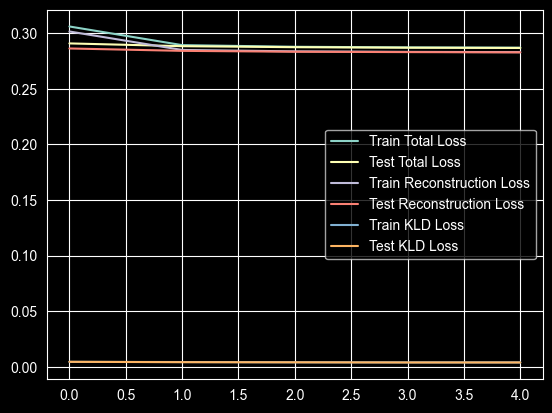

In [3]:
plt.plot(train_hist['train_loss'], label='Train Total Loss')
plt.plot(train_hist['test_loss'], label='Test Total Loss')
plt.plot(train_hist['train_rec'], label='Train Reconstruction Loss')
plt.plot(train_hist['test_rec'], label='Test Reconstruction Loss')
plt.plot(train_hist['train_kld'], label='Train KLD Loss')
plt.plot(train_hist['test_kld'], label='Test KLD Loss')
plt.legend()
plt.show()

In [4]:
# Get all test latents and plot in 2D
cvae.eval()
test_mus = []
test_conditions = []
with torch.no_grad():
    for x in test_dl:
        x = x.to(device)
        mu, logvar = cvae.encode(x.pixel_values)
        test_mus.append(mu.detach().cpu().numpy())
        test_conditions.append(getattr(x.factors, active_features[0]).detach().cpu().numpy())

test_mus = np.concat(test_mus, axis=0)
test_conditions = np.concat(test_conditions)
test_mus = test_mus.reshape((test_mus.shape[0], -1))
print(test_mus.shape)
print(test_conditions.shape)

(96000, 2048)
(96000,)


In [5]:
from sklearn.manifold import TSNE

test_mus_2d = TSNE(n_components=2).fit_transform(test_mus)
print(test_mus_2d.shape)

(96000, 2)


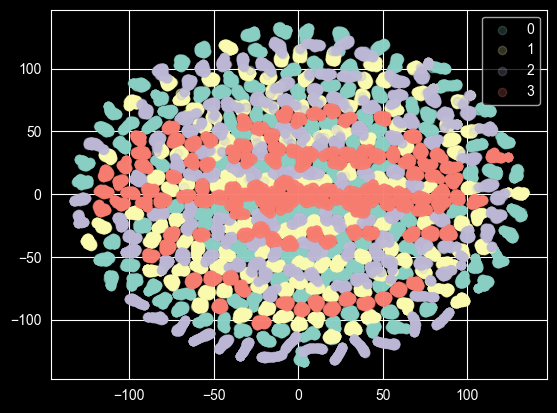

In [6]:
for i in np.unique(test_conditions):
    c = test_conditions == i
    plt.scatter(test_mus_2d[c, 0], test_mus_2d[c, 1], label=i, alpha=0.2)
plt.legend()
plt.show()

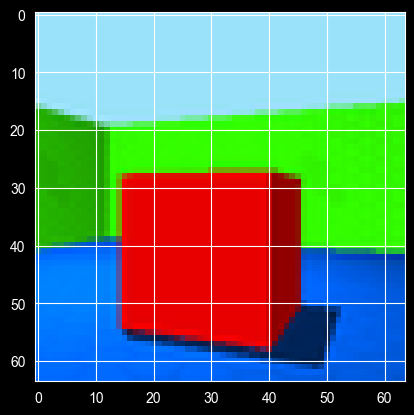

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-18.504108..11.599566].


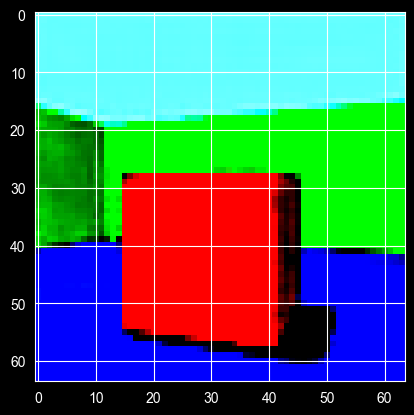

In [25]:
cvae.eval()
idx = 10
with torch.no_grad():
    for x in test_dl:
        x = x.to(device)
        out = cvae(
            pixel_values=x.pixel_values,
            feature_ids={feature: getattr(x.factors, feature) for feature in active_features}
        )
        plt.imshow(np.transpose(x.pixel_values[idx, ...].detach().cpu().numpy(), (1, 2, 0)))
        plt.show()
        plt.imshow(np.transpose(out.rec[idx, ...].detach().cpu().numpy(), (1, 2, 0)))
        plt.show()
        break


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-19.760191..11.84246].


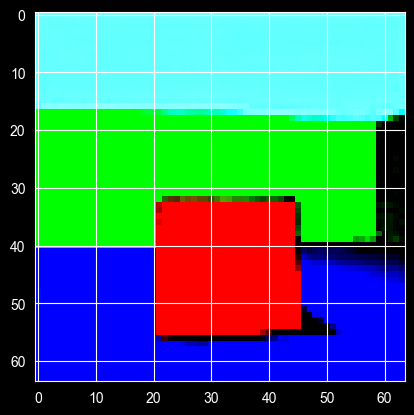

In [33]:
cvae.eval()
feature_ids = {
    'floor_hue': HueColor.BLUE.value,
    'wall_hue': HueColor.GREEN.value,
    'obj_hue': HueColor.RED.value,
    'shape': Shape.CUBE.value
}
with torch.no_grad():
    res = cvae.conditional_simulation(
        feature_id=feature_ids
    )
    res = res.detach().cpu().numpy()
    # res = (res - res.min()) / (res.max() - res.min())
    plt.imshow(np.transpose(res, (1, 2, 0)))
    plt.show()
